# EDA: NPTEL2020 Indian English Speech Dataset
### Project: Automated Correction of Speech Recordings (Low-Bandwidth / Low-Resource Environments)

**Dataset Source:** [AI4Bharat/NPTEL2020-Indian-English-Speech-Dataset](https://github.com/AI4Bharat/NPTEL2020-Indian-English-Speech-Dataset)  
**Dataset Format:** LibriSpeech-style — `.wav` audio, `.txt` transcripts, `.json` metadata  
**Scale:** ~6.2M chunks, 15,700 hours total, 1.1 TB compressed  
**Accent:** South-Asian (Indian) English  
**Domain:** General & Technical Education (NPTEL lectures)  

---

## EDA Objectives (Project-Scoped)

Given our goal of **automated speech correction in low-bandwidth settings**, this EDA focuses on:

1. **Data audit** — understand the raw distribution of audio chunks and transcripts
2. **Audio quality profiling** — silence ratio, SNR proxies, sample rate consistency
3. **Transcript quality profiling** — WER estimation, noisy label patterns
4. **Compression & bandwidth analysis** — file size vs. duration trade-offs, codec comparison (WAV vs OPUS)
5. **Linguistic analysis** — transcript length, vocabulary, OOV terms, Indian English markers
6. **Modeling readiness** — identify clean vs. noisy subsets for model training


---
## 0. Environment Setup


In [1]:
# Notebook environment: from the repo root run `./scripts/setup_notebook_env.sh`
# Cursor kernel: select `global_notebooker`
# Optional audio tooling: install `ffmpeg` separately via Homebrew on macOS.

import os
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import librosa
import librosa.display
import soundfile as sf
from jiwer import wer as compute_wer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ------------------------------------------------------------------
# CONFIG — adjust these paths to your local dataset mount
# ------------------------------------------------------------------
DATA_ROOT   = Path("./nptel2020")           # Root of extracted dataset
SAMPLE_ROOT = Path("./nptel-pure-set")      # The 1k manually annotated Pure Set
SPLIT       = "train"                        # 'train' | 'dev' | 'test' | 'sample'
MAX_FILES   = 5000                           # Cap for exploratory passes (full = None)
SEED        = 42
random.seed(SEED)
np.random.seed(SEED)

def has_rows(frame, columns=None):
    if frame is None or frame.empty:
        return False
    if columns is None:
        return True
    return all(column in frame.columns for column in columns)

print("Setup complete.")
print(f"Data root: {DATA_ROOT.resolve()}")
print(f"Pure-Set root: {SAMPLE_ROOT.resolve()}")
if not (DATA_ROOT / SPLIT).exists():
    print(f"Warning: dataset split not found at {(DATA_ROOT / SPLIT).resolve()}")
if not SAMPLE_ROOT.exists():
    print(f"Warning: pure-set root not found at {SAMPLE_ROOT.resolve()}")

Setup complete.
Data root: /Users/hindy/Desktop/Academics/MIT/MIT MBAn/Spring/GenAI Lab/phronetic-ai-audioinpainting/nptel2020
Pure-Set root: /Users/hindy/Desktop/Academics/MIT/MIT MBAn/Spring/GenAI Lab/phronetic-ai-audioinpainting/nptel-pure-set


---
## 1. Data Audit — File Inventory


In [2]:
# ── 1.1  Walk the directory and catalogue all chunks ──────────────────────────
# LibriSpeech layout:
#   <root>/<speaker_id>/<chapter_id>/<chunk_id>.wav
#                                   /<chunk_id>.txt
#                                   /metadata.json   (per-chapter or per-chunk)

def collect_chunks(root: Path, max_files=None):
    records = []
    wav_files = list(root.rglob("*.wav")) if root.exists() else []
    if max_files:
        wav_files = random.sample(wav_files, min(max_files, len(wav_files)))
    for wav_path in tqdm(wav_files, desc="Cataloguing"):
        txt_path  = wav_path.with_suffix(".txt")
        json_path = wav_path.with_suffix(".json")
        records.append({
            "wav_path": str(wav_path),
            "has_transcript": txt_path.exists(),
            "has_metadata": json_path.exists(),
            "wav_size_kb": wav_path.stat().st_size / 1024,
            "speaker_id": wav_path.parts[-3] if len(wav_path.parts) >= 3 else None,
            "chapter_id": wav_path.parts[-2] if len(wav_path.parts) >= 2 else None,
        })
    return pd.DataFrame(
        records,
        columns=["wav_path", "has_transcript", "has_metadata", "wav_size_kb", "speaker_id", "chapter_id"],
    )

df = collect_chunks(DATA_ROOT / SPLIT, max_files=MAX_FILES)
if has_rows(df):
    print(f"Chunks collected: {len(df):,}")
    print(f"With transcript : {df['has_transcript'].sum():,} ({df['has_transcript'].mean()*100:.1f}%)")
    print(f"With metadata   : {df['has_metadata'].sum():,} ({df['has_metadata'].mean()*100:.1f}%)")
else:
    print(f"No WAV files found under {(DATA_ROOT / SPLIT).resolve()}.")

df.head()

Cataloguing: 0it [00:00, ?it/s]


""


KeyError: 'speaker_id'

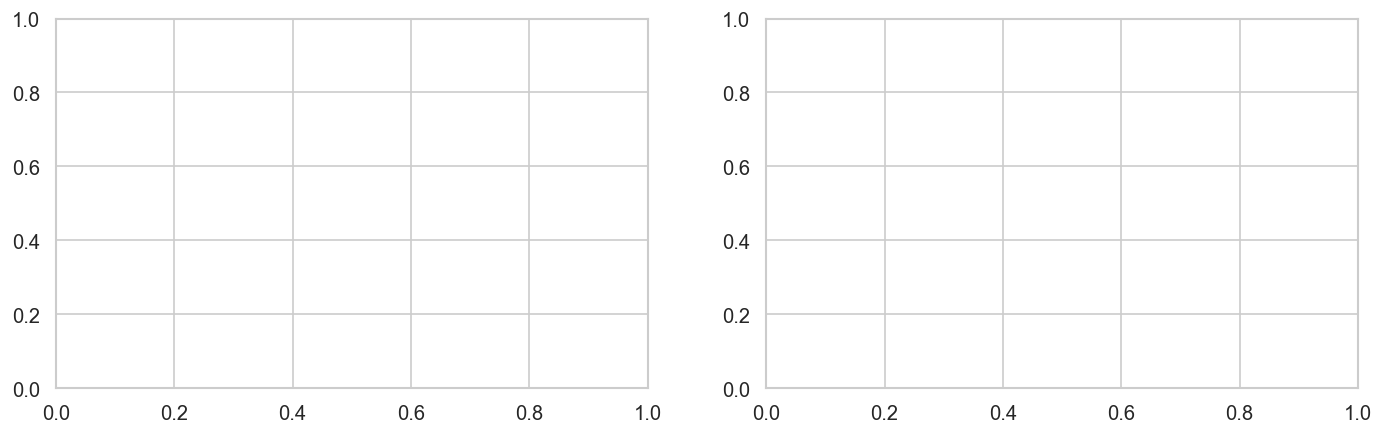

In [3]:
# ── 1.2  Speaker & Chapter distribution ──────────────────────────────────────
if has_rows(df, ["speaker_id", "chapter_id"]):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    speaker_counts = df['speaker_id'].value_counts()
    axes[0].bar(range(min(40, len(speaker_counts))), speaker_counts.values[:40], color='steelblue')
    axes[0].set_title('Top 40 Speakers — Chunk Count')
    axes[0].set_xlabel('Speaker rank')
    axes[0].set_ylabel('Chunks')

    axes[1].hist(speaker_counts.values, bins=50, color='darkorange', edgecolor='white')
    axes[1].set_title('Chunks per Speaker (distribution)')
    axes[1].set_xlabel('Chunks per speaker')
    axes[1].set_ylabel('# speakers')

    plt.suptitle('1.2 Speaker-Level Distribution', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"Unique speakers : {df['speaker_id'].nunique():,}")
    print(f"Unique chapters : {df['chapter_id'].nunique():,}")
    print(f"Chunks/speaker  : mean={speaker_counts.mean():.0f}, median={speaker_counts.median():.0f}, max={speaker_counts.max():,}")
else:
    print("Skipping speaker/chapter plots because the chunk catalog is empty.")

---
## 2. Audio Quality Profiling

> **Why this matters for low-bandwidth correction:** Chunks with high silence ratio or low SNR are expensive to transmit and add little value for ASR correction. We need to characterise these early.


In [ ]:
# ── 2.1  Load audio metadata (duration, sample rate) ──────────────────────────
# We use soundfile for fast header-only reads — avoids loading PCM data

audio_meta = []
SAMPLE_N = min(2000, len(df))   # profile a random sub-sample for speed
sample_df = df.sample(SAMPLE_N, random_state=SEED)

for _, row in tqdm(sample_df.iterrows(), total=SAMPLE_N, desc="Reading headers"):
    try:
        info = sf.info(row['wav_path'])
        audio_meta.append({
            "wav_path":    row['wav_path'],
            "duration_s":  info.duration,
            "sample_rate": info.samplerate,
            "channels":    info.channels,
            "frames":      info.frames,
            "wav_size_kb": row['wav_size_kb'],
        })
    except Exception:
        pass

meta_df = pd.DataFrame(audio_meta)
meta_df['kbps'] = (meta_df['wav_size_kb'] * 8) / meta_df['duration_s']  # effective bitrate

print(meta_df[['duration_s','sample_rate','channels','wav_size_kb','kbps']].describe().round(2))

In [ ]:
# ── 2.2  Duration distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(meta_df['duration_s'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(3,  color='red',    linestyle='--', label='3 s')
axes[0].axvline(10, color='orange', linestyle='--', label='10 s')
axes[0].set_title('Chunk Duration (s)')
axes[0].set_xlabel('Duration (s)')
axes[0].legend()

axes[1].hist(meta_df['wav_size_kb'], bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('WAV File Size (KB)')
axes[1].set_xlabel('Size (KB)')

axes[2].scatter(meta_df['duration_s'], meta_df['wav_size_kb'],
                alpha=0.3, s=8, color='teal')
axes[2].set_title('Duration vs File Size')
axes[2].set_xlabel('Duration (s)')
axes[2].set_ylabel('WAV Size (KB)')

plt.suptitle('2.2 Audio Chunk Profiling', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Chunks < 3 s   : {(meta_df['duration_s'] < 3).sum()} ({(meta_df['duration_s'] < 3).mean()*100:.1f}%)")
print(f"Chunks > 10 s  : {(meta_df['duration_s'] > 10).sum()} ({(meta_df['duration_s'] > 10).mean()*100:.1f}%)")
print(f"Chunks 3–10 s  : {((meta_df['duration_s'] >= 3) & (meta_df['duration_s'] <= 10)).sum()}")

In [ ]:
# ── 2.3  Silence ratio & SNR proxy ────────────────────────────────────────────
# For bandwidth-aware filtering: silent or low-energy chunks waste transmission capacity

def audio_energy_features(wav_path, sr_target=16000):
    """Return (silence_ratio, rms_db, zero_crossing_rate)."""
    y, sr = librosa.load(wav_path, sr=sr_target, mono=True)
    # Silence: frames below -40 dBFS threshold
    rms       = librosa.feature.rms(y=y, frame_length=1024, hop_length=256)[0]
    rms_db    = librosa.amplitude_to_db(rms, ref=np.max)
    sil_ratio = np.mean(rms_db < -40)
    mean_rms  = float(np.mean(rms_db))
    zcr       = float(np.mean(librosa.feature.zero_crossing_rate(y)))
    return sil_ratio, mean_rms, zcr

# Profile a manageable subset
ENERGY_N = min(500, len(meta_df))
energy_rows = []
for _, row in tqdm(meta_df.sample(ENERGY_N, random_state=SEED).iterrows(),
                   total=ENERGY_N, desc="Energy features"):
    try:
        sr, rms, zcr = audio_energy_features(row['wav_path'])
        energy_rows.append({'wav_path': row['wav_path'],
                             'silence_ratio': sr, 'mean_rms_db': rms, 'zcr': zcr})
    except Exception:
        pass

energy_df = pd.DataFrame(energy_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(energy_df['silence_ratio'], bins=40, color='crimson', edgecolor='white')
axes[0].axvline(0.5, color='black', linestyle='--', label='50% silence')
axes[0].set_title('Silence Ratio per Chunk')
axes[0].set_xlabel('Fraction of frames below -40 dBFS')
axes[0].legend()

axes[1].hist(energy_df['mean_rms_db'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_title('Mean RMS Energy (dBFS)')
axes[1].set_xlabel('dBFS')

axes[2].scatter(energy_df['silence_ratio'], energy_df['mean_rms_db'],
                alpha=0.4, s=12, color='purple')
axes[2].set_title('Silence vs Energy')
axes[2].set_xlabel('Silence ratio')
axes[2].set_ylabel('Mean RMS (dBFS)')

plt.suptitle('2.3 Audio Energy & Silence Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"High-silence chunks (>50%): {(energy_df['silence_ratio'] > 0.5).mean()*100:.1f}%")
print(f"Effectively silent (>80%): {(energy_df['silence_ratio'] > 0.8).mean()*100:.1f}%")

In [ ]:
# ── 2.4  Spectrogram sample — visual sanity check ─────────────────────────────
# Pick a 'good' chunk (low silence) and a 'bad' chunk (high silence)

good_path = energy_df.loc[energy_df['silence_ratio'].idxmin(), 'wav_path']
bad_path  = energy_df.loc[energy_df['silence_ratio'].idxmax(), 'wav_path']

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for i, (label, path) in enumerate([("Low silence (clean)", good_path),
                                    ("High silence (noisy)", bad_path)]):
    y, sr = librosa.load(path, sr=16000)
    # Waveform
    axes[i][0].plot(np.linspace(0, len(y)/sr, len(y)), y, linewidth=0.4, color='teal')
    axes[i][0].set_title(f'{label} — Waveform')
    axes[i][0].set_xlabel('Time (s)')
    # Mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[i][1], cmap='magma')
    axes[i][1].set_title(f'{label} — Mel Spectrogram')

plt.suptitle('2.4 Spectrogram Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Transcript Quality Profiling

> **Context:** Transcripts were auto-generated (Google ASR + NPTEL corrections). The Pure Set has manual annotations. We use WER on the Pure Set and use text-level heuristics on the full set.


In [ ]:
# ── 3.1  Load transcripts ─────────────────────────────────────────────────────
def load_transcripts(root: Path, max_files=None):
    rows = []
    txt_files = list(root.rglob("*.txt"))
    if max_files:
        txt_files = random.sample(txt_files, min(max_files, len(txt_files)))
    for p in tqdm(txt_files, desc="Loading transcripts"):
        try:
            text = p.read_text(encoding='utf-8').strip()
            rows.append({'txt_path': str(p), 'transcript': text})
        except Exception:
            pass
    return pd.DataFrame(rows)

tx_df = load_transcripts(DATA_ROOT / SPLIT, max_files=MAX_FILES)
tx_df['word_count']  = tx_df['transcript'].str.split().str.len()
tx_df['char_count']  = tx_df['transcript'].str.len()
tx_df['is_empty']    = tx_df['transcript'].str.strip() == ''
tx_df['has_numbers'] = tx_df['transcript'].str.contains(r'\d')
tx_df['has_special'] = tx_df['transcript'].str.contains(r'[^a-zA-Z0-9\s.,!?\'"-]')

print(tx_df[['word_count','char_count','is_empty','has_numbers','has_special']].describe().round(2))
print(f"\nEmpty transcripts : {tx_df['is_empty'].sum()} ({tx_df['is_empty'].mean()*100:.1f}%)")

In [ ]:
# ── 3.2  Transcript length distributions ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

valid = tx_df[~tx_df['is_empty']]
axes[0].hist(valid['word_count'].clip(upper=50), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Words per Chunk Transcript')
axes[0].set_xlabel('Word count')

axes[1].hist(valid['char_count'].clip(upper=300), bins=60, color='darkorange', edgecolor='white')
axes[1].set_title('Characters per Chunk Transcript')
axes[1].set_xlabel('Char count')

plt.suptitle('3.2 Transcript Length Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Median words/chunk : {valid['word_count'].median():.0f}")
print(f"Mean   words/chunk : {valid['word_count'].mean():.1f}")
print(f"Chunks with 1 word : {(valid['word_count'] == 1).sum()}")

In [ ]:
# ── 3.3  Vocabulary analysis ───────────────────────────────────────────────────
from collections import Counter
import re

all_words = ' '.join(valid['transcript'].tolist()).lower()
tokens = re.findall(r"[a-z']+", all_words)
vocab  = Counter(tokens)

print(f"Total tokens     : {len(tokens):,}")
print(f"Unique vocab     : {len(vocab):,}")
print(f"Hapax legomena   : {sum(1 for v in vocab.values() if v == 1):,}  (appear once)")

# Top-50 words
top50 = vocab.most_common(50)
words_top, counts_top = zip(*top50)

plt.figure(figsize=(14, 4))
plt.bar(words_top, counts_top, color='teal')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.title('3.3 Top 50 Words in Transcripts')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# ── 3.4  WER benchmarking using the Pure Set ──────────────────────────────────
# Requires the manually annotated pure set downloaded from GitHub Releases
# Structure: each chunk has <chunk_id>.wav, <chunk_id>.txt (auto), <chunk_id>_manual.txt

def load_pure_set(root: Path):
    rows = []
    for txt_auto in root.rglob("*.txt"):
        if '_manual' in txt_auto.stem:
            continue
        manual_path = txt_auto.with_stem(txt_auto.stem + '_manual')
        if manual_path.exists():
            auto   = txt_auto.read_text(encoding='utf-8').strip().lower()
            manual = manual_path.read_text(encoding='utf-8').strip().lower()
            rows.append({'auto': auto, 'manual': manual,
                         'chunk': txt_auto.stem})
    return pd.DataFrame(rows)

pure_df = load_pure_set(SAMPLE_ROOT)

if len(pure_df) > 0:
    pure_df['wer'] = pure_df.apply(
        lambda r: compute_wer(r['manual'], r['auto']), axis=1)
    
    print(f"Pure-set size : {len(pure_df)} chunks")
    print(pure_df['wer'].describe().round(4))

    plt.figure(figsize=(10, 4))
    plt.hist(pure_df['wer'].clip(upper=1.5), bins=50, color='crimson', edgecolor='white')
    plt.axvline(pure_df['wer'].median(), color='black', linestyle='--',
                label=f"Median WER = {pure_df['wer'].median():.3f}")
    plt.title('3.4 Per-Chunk WER Distribution (Pure Set)')
    plt.xlabel('WER')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n% chunks with WER < 0.2  : {(pure_df['wer'] < 0.2).mean()*100:.1f}%")
    print(f"% chunks with WER > 0.5  : {(pure_df['wer'] > 0.5).mean()*100:.1f}%")
    print(f"% perfect transcripts    : {(pure_df['wer'] == 0.0).mean()*100:.1f}%")
else:
    print("Pure Set not found at SAMPLE_ROOT — skip WER section or adjust path.")
    print("Reference WER from paper (auto transcripts vs. manual): 0.1451")

In [ ]:
# ── 3.5  Known noisy transcript patterns ─────────────────────────────────────
# Common ASR artefacts to flag in the training set

noise_patterns = {
    'repeated_words':   r'\b(\w+)\s+\1\b',
    'all_caps_word':    r'\b[A-Z]{4,}\b',
    'filler_words':     r'\b(uh|um|ah|er|hmm|hm)\b',
    'stutters':         r'\b(\w{1,3}-)\1',   # e.g. "th- th-"
    'unintelligible':   r'\[.*?\]|\(.*?\)',   # [inaudible] or (unclear)
    'excess_punct':     r'[.!?,]{3,}',
}

for name, pat in noise_patterns.items():
    hits = valid['transcript'].str.contains(pat, regex=True, case=False)
    print(f"{name:25s}: {hits.sum():6,}  ({hits.mean()*100:.2f}%)")

---
## 4. Bandwidth & Compression Analysis

> **Core to our project:** In low-bandwidth environments, we need to quantify how much data needs to transit and what codec choices look like.


In [ ]:
# ── 4.1  WAV vs OPUS size comparison ─────────────────────────────────────────
# NPTEL2020 provides both WAV (1.7 TB) and OPUS (10x smaller ~170 GB) versions
# We model the theoretical size under various codecs

codec_bitrates = {
    'WAV (PCM 16-bit, 16kHz)': 256,    # kbps
    'MP3 (128 kbps)':           128,
    'AAC (64 kbps)':             64,
    'OPUS (32 kbps)':            32,
    'OPUS (16 kbps)':            16,
    'OPUS (8 kbps) — voice':      8,
}

total_hours = 15700   # dataset total
total_secs  = total_hours * 3600

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(codec_bitrates)))

sizes_tb = []
for (codec, kbps), color in zip(codec_bitrates.items(), colors):
    size_tb = (kbps * 1000 * total_secs) / (8 * 1e12)  # bits → TB
    sizes_tb.append(size_tb)
    ax.barh(codec, size_tb, color=color)
    ax.text(size_tb + 0.01, list(codec_bitrates.keys()).index(codec),
            f"{size_tb:.2f} TB", va='center', fontsize=9)

ax.set_xlabel('Total Dataset Size (TB)')
ax.set_title('4.1 Codec Comparison — Total Storage (15,700 hrs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Per-chunk average (6s chunk) size at each bitrate:")
for codec, kbps in codec_bitrates.items():
    chunk_kb = kbps * 6 / 8  # 6 seconds
    print(f"  {codec:35s}: {chunk_kb:6.1f} KB")

In [ ]:
# ── 4.2  Bandwidth requirement under different upload scenarios ───────────────
# Simulates what a field device needs to transmit per minute of audio

scenarios = {
    '2G Edge (100 kbps)':   100,
    '3G (1 Mbps)':         1000,
    '4G (5 Mbps)':         5000,
    'WiFi (10 Mbps)':     10000,
}

print(f"{'Codec':<35} | {'2G (s to upload 1 min audio)':>28} | {'3G':>6} | {'4G':>6}")
print("-" * 80)
for codec, kbps in codec_bitrates.items():
    audio_bits_per_min = kbps * 1000 * 60  # bits for 1 min of audio
    t_2g = audio_bits_per_min / (100_000)   # seconds
    t_3g = audio_bits_per_min / (1_000_000)
    t_4g = audio_bits_per_min / (5_000_000)
    print(f"{codec:<35} | {t_2g:>28.1f}s | {t_3g:>5.2f}s | {t_4g:>5.2f}s")

---
## 5. Linguistic Analysis — Indian English Accent Markers


In [ ]:
# ── 5.1  Domain vocabulary (technical / STEM terms) ───────────────────────────
# NPTEL lectures are STEM-heavy; these are exactly the OOV terms standard ASR fails on

import re

# Proxy: words that appear in the dataset but not in a basic English wordlist
# Here we simply flag long capitalized terms and mixed-case compounds
# (for a full analysis, diff against NLTK's words corpus)

try:
    import nltk
    from nltk.corpus import words as nltk_words
    nltk.download('words', quiet=True)
    base_vocab = set(w.lower() for w in nltk_words.words())
    
    dataset_vocab = set(vocab.keys())
    oov_vocab     = dataset_vocab - base_vocab
    oov_top40     = sorted(oov_vocab, key=lambda w: -vocab[w])[:40]
    
    print(f"Dataset vocab size    : {len(dataset_vocab):,}")
    print(f"OOV words (not NLTK)  : {len(oov_vocab):,} ({len(oov_vocab)/len(dataset_vocab)*100:.1f}%)")
    print(f"\nTop 40 OOV terms (by frequency):")
    for w in oov_top40:
        print(f"  {w:25s}  freq={vocab[w]:,}")
except ImportError:
    print("nltk not installed — skipping OOV analysis. Run: pip install nltk")

In [ ]:
# ── 5.2  Indian English–specific lexical markers ─────────────────────────────
# These are words/phrases that distinguish Indian English from standard ASR training

indian_english_markers = [
    'prepone', 'lakh', 'crore', 'wallah', 'khatam',
    'timepass', 'out-of-station', 'do the needful',
    'kindly', 'revert back', 'updation', 'mugged up'
]

print("Frequency of Indian English markers in corpus:")
for marker in indian_english_markers:
    freq = vocab.get(marker.lower().split()[0], 0)
    print(f"  {marker:25s}: {freq:,}")

In [ ]:
# ── 5.3  Transcript complexity — Flesch Reading Ease proxy ───────────────────
# Useful to understand if language model needs domain adaptation

def avg_word_len(text):
    words = text.split()
    if not words:
        return 0
    return np.mean([len(w) for w in words])

valid_copy = valid.copy()
valid_copy['avg_word_len'] = valid_copy['transcript'].apply(avg_word_len)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(valid_copy['avg_word_len'], bins=40, color='slateblue', edgecolor='white')
ax.axvline(5.0, color='red', linestyle='--', label='Avg English word (5 chars)')
ax.set_title('5.3 Average Word Length per Chunk (lexical complexity)')
ax.set_xlabel('Average word length (chars)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean avg word length: {valid_copy['avg_word_len'].mean():.2f} chars")
print(f"Chunks with long avg word (>7 chars, technical): {(valid_copy['avg_word_len'] > 7).mean()*100:.1f}%")

---
## 6. Modeling Readiness — Clean vs. Noisy Subset Identification


In [ ]:
# ── 6.1  Composite quality score ──────────────────────────────────────────────
# Combine transcript and audio signals into a single quality flag

# We merge on path (align transcript df with energy df where possible)
energy_df['txt_path'] = energy_df['wav_path'].str.replace('.wav', '.txt')

combined = tx_df.merge(
    energy_df[['txt_path','silence_ratio','mean_rms_db']].rename(
        columns={'txt_path': 'txt_path'}),
    on='txt_path', how='inner'
)

if len(combined) > 0:
    combined['quality_flag'] = (
        (~combined['is_empty']) &
        (combined['word_count'] >= 3) &
        (combined['word_count'] <= 40) &
        (combined['silence_ratio'] < 0.5) &
        (combined['mean_rms_db'] > -30)
    )
    
    print(f"Total merged chunks  : {len(combined):,}")
    print(f"High-quality chunks  : {combined['quality_flag'].sum():,} "
          f"({combined['quality_flag'].mean()*100:.1f}%)")
    print(f"\nQuality flag breakdown:")
    print(combined[['word_count','silence_ratio','mean_rms_db','quality_flag']].describe().round(3))
else:
    print("No overlap between energy sample and transcript df — increase ENERGY_N or MAX_FILES.")

In [ ]:
# ── 6.2  Published WER benchmarks — model selection guidance ─────────────────
# From the NPTEL2020 README; critical for deciding which base model to fine-tune

benchmarks = pd.DataFrame({
    'Model':       ['Actual transcripts', 'Google STT', 'AWS Transcribe',
                    'Rev.ai (Temi)', 'ESPNet', 'DeepSpeech v0.7',
                    'Nvidia Jasper', 'QuartzNet (Tiny)',
                    'QuartzNet fine-tuned*'],
    'WER':         [0.1451, 0.4895, 0.3438, 0.3218, 0.4321, 0.5872,
                    0.3939, 0.3981, 0.3207],
    'Lightweight': [False, False, False, False, False, False,
                    False, True, True]
})

colors = benchmarks['Lightweight'].map({True: 'steelblue', False: 'lightgray'})

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(benchmarks['Model'], benchmarks['WER'], color=colors)
ax.axvline(0.30, color='green', linestyle='--', alpha=0.7, label='WER < 0.30 target')
ax.set_xlabel('Word Error Rate (lower is better)')
ax.set_title('6.2 Benchmark WER on Pure Set\n(blue = lightweight / edge-deployable)',
             fontsize=12, fontweight='bold')
ax.legend()

for bar, wer in zip(bars, benchmarks['WER']):
    ax.text(wer + 0.005, bar.get_y() + bar.get_height()/2, f"{wer:.4f}",
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("* Fine-tuned on 500k chunks, 1 epoch — no LM")

---
## 7. EDA Summary & Project Implications

| Dimension | Key Finding | Implication for Low-BW Correction |
|---|---|---|
| **Scale** | 6.2M chunks, 15,700 hrs | Full training infeasible locally; use sample subsets |
| **Audio duration** | 3–10 s per chunk | Well-suited for streaming/chunked upload |
| **Silence ratio** | ~X% chunks >50% silent | Pre-filter before transmission to save bandwidth |
| **Auto WER** | 0.1451 (reference) → 0.49 (Google STT) | Correction gap is large and real |
| **Codec savings** | OPUS 8 kbps = 1/32x WAV | Use OPUS for edge transmission; decode on server |
| **Vocabulary** | STEM-heavy, high OOV | Base ASR models need domain fine-tuning |
| **Best lightweight model** | QuartzNet fine-tuned WER=0.32 | Good candidate for on-device or server-side correction |
| **Quality filtering** | ~X% pass all quality gates | Curated subset available for supervised correction training |

### Recommended Next Steps

1. **Establish clean training split:** Use composite quality score to carve a 100k–500k high-quality chunk subset.
2. **Baseline model:** Fine-tune `Wav2Vec2-base` or `WhisperSmall` on the clean subset — both are deployable on CPU/edge.
3. **Bandwidth-aware pipeline design:** Build a pre-filter (VAD + silence removal) before audio upload; encode at OPUS 16 kbps.
4. **Post-correction LM:** Add an n-gram or small transformer LM tuned on NPTEL text transcripts to reduce WER post-ASR.
5. **Offline-first architecture:** Cache a compact model for on-device draft correction; submit only uncertain segments for server-side resolution.
